In [1]:
# ============================================================
# TEAM C / INTEGRATION - STEP 1
# Install dependencies
# ============================================================

!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.9/68.9 kB 7.3 MB/s eta 0:00:00


In [2]:
# ============================================================
# STEP 2
# Mount Google Drive
# ============================================================

from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
# ============================================================
# STEP 3
# Imports
# ============================================================

from pathlib import Path
import json
import cv2
import numpy as np
import tensorflow as tf

from ultralytics import YOLO

print("TensorFlow:", tf.__version__)

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
TensorFlow: 2.20.0


In [4]:
# ============================================================
# STEP 4
# Model paths
# ============================================================

BASE_DIR = Path(
    "/content/drive/MyDrive/Colab Notebooks/Deep Learning/Food Detection"
)

YOLO_MODEL_PATH = (
    BASE_DIR
    / "FoodDetectionRuns"
    / "yolov8s_food41_enriched_v1"
    / "weights"
    / "best.pt"
)

MASS_MODEL_PATH = (
    BASE_DIR
    / "mobilenetv2_mass_estimator_v1.keras"
)

LOOKUP_PATH = (
    BASE_DIR
    / "kcal_per_gram_food41.json"
)


print("YOLO:", YOLO_MODEL_PATH)
print("Mass:", MASS_MODEL_PATH)
print("Lookup:", LOOKUP_PATH)

print("\nExists:")
print("YOLO:", YOLO_MODEL_PATH.exists())
print("Mass:", MASS_MODEL_PATH.exists())
print("Lookup:", LOOKUP_PATH.exists())

YOLO: /content/drive/MyDrive/Colab Notebooks/Deep Learning/Food Detection/FoodDetectionRuns/yolov8s_food41_enriched_v1/weights/best.pt
Mass: /content/drive/MyDrive/Colab Notebooks/Deep Learning/Food Detection/mobilenetv2_mass_estimator_v1.keras
Lookup: /content/drive/MyDrive/Colab Notebooks/Deep Learning/Food Detection/kcal_per_gram_food41.json

Exists:
YOLO: True
Mass: True
Lookup: True


In [5]:
# ============================================================
# STEP 5
# Load Team A + Team B
# ============================================================

detection_model = YOLO(
    str(YOLO_MODEL_PATH)
)

mass_model = tf.keras.models.load_model(
    str(MASS_MODEL_PATH)
)

with open(
    LOOKUP_PATH,
    "r",
    encoding="utf-8"
) as f:
    KCAL_PER_GRAM = json.load(f)


print("YOLO loaded")
print("Mass model loaded")
print(
    "Nutrition classes:",
    len(KCAL_PER_GRAM)
)

YOLO loaded
Mass model loaded
Nutrition classes: 41


In [6]:
# ============================================================
# STEP 6
# Team A API - Food Detection
# ============================================================

def detect_food(
    image,
    detection_model=detection_model,
    conf=0.25,
    imgsz=640
):
    """
    Detect food objects in a BGR OpenCV image.

    Returns:
        List of dictionaries:
        [
            {
                "bbox": [x1, y1, x2, y2],
                "confidence": float,
                "class_id": int,
                "class_name": str
            }
        ]
    """

    results = detection_model.predict(
        source=image,
        conf=conf,
        imgsz=imgsz,
        verbose=False
    )

    detections = []

    h, w = image.shape[:2]

    for result in results:

        for box in result.boxes:

            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()

            # Clamp coordinates to image boundaries
            x1 = max(0, min(int(round(x1)), w - 1))
            y1 = max(0, min(int(round(y1)), h - 1))
            x2 = max(0, min(int(round(x2)), w))
            y2 = max(0, min(int(round(y2)), h))

            class_id = int(box.cls[0].item())
            confidence = float(box.conf[0].item())

            detections.append({
                "bbox": [x1, y1, x2, y2],
                "confidence": round(confidence, 4),
                "class_id": class_id,
                "class_name": detection_model.names[class_id]
            })

    # Highest confidence first
    detections.sort(
        key=lambda x: x["confidence"],
        reverse=True
    )

    return detections

In [7]:
# ============================================================
# STEP 7
# Team B API - Mass Estimation
# ============================================================

def estimate_mass_bgr(
    food_crop,
    mass_model=mass_model
):
    """
    Estimate food mass from a BGR OpenCV crop.

    Returns:
        estimated mass in grams
    """

    if food_crop is None or food_crop.size == 0:
        raise ValueError("Empty food crop received.")

    # BGR -> RGB
    image_rgb = cv2.cvtColor(
        food_crop,
        cv2.COLOR_BGR2RGB
    )

    # Same input size used during training
    image_resized = cv2.resize(
        image_rgb,
        (224, 224)
    )

    image_array = image_resized.astype(np.float32)

    # Add batch dimension
    image_array = np.expand_dims(
        image_array,
        axis=0
    )

    prediction = mass_model.predict(
        image_array,
        verbose=0
    )

    estimated_mass = float(
        prediction[0][0]
    )

    # Mass cannot physically be negative
    estimated_mass = max(
        0.0,
        estimated_mass
    )

    return round(
        estimated_mass,
        2
    )

In [8]:
# ============================================================
# STEP 8
# Team B API - Calorie Estimation
# ============================================================

def estimate_food_nutrition(
    food_crop,
    class_name
):
    """
    Estimate mass and calories for one detected food.
    """

    if class_name not in KCAL_PER_GRAM:
        raise ValueError(
            f"No kcal/g value found for class: {class_name}"
        )

    estimated_mass_g = estimate_mass_bgr(
        food_crop
    )

    kcal_per_gram = float(
        KCAL_PER_GRAM[class_name]
    )

    estimated_calories = (
        estimated_mass_g
        * kcal_per_gram
    )

    return {
        "food_label": class_name,
        "estimated_mass_g": round(
            estimated_mass_g,
            2
        ),
        "kcal_per_gram": round(
            kcal_per_gram,
            3
        ),
        "estimated_calories": round(
            estimated_calories,
            2
        )
    }

In [9]:
# ============================================================
# STEP 9
# Complete A + B Integration
# ============================================================

def analyze_food(
    image,
    conf=0.25,
    imgsz=640
):
    """
    Complete food analysis pipeline:

    Image
      -> Team A: food detection
      -> Crop detected foods
      -> Team B: mass estimation
      -> Nutrition lookup
      -> Calorie estimation

    Input:
        image: BGR OpenCV image

    Returns:
        List of dictionaries
    """

    if image is None or image.size == 0:
        raise ValueError("Invalid input image.")

    detections = detect_food(
        image,
        conf=conf,
        imgsz=imgsz
    )

    results = []

    for detection in detections:

        x1, y1, x2, y2 = detection["bbox"]

        # Crop detected food
        food_crop = image[
            y1:y2,
            x1:x2
        ]

        if food_crop.size == 0:
            continue

        class_name = detection["class_name"]

        # Team B
        nutrition = estimate_food_nutrition(
            food_crop,
            class_name
        )

        results.append({
            "bbox": detection["bbox"],
            "confidence": detection["confidence"],
            "class_id": detection["class_id"],
            "class_name": class_name,

            "estimated_mass_g":
                nutrition["estimated_mass_g"],

            "kcal_per_gram":
                nutrition["kcal_per_gram"],

            "estimated_calories":
                nutrition["estimated_calories"]
        })

    return results

In [10]:
# ============================================================
# STEP 10
# Static Image End-to-End Test
# ============================================================

TEST_IMAGE_PATH = "/content/drive/MyDrive/Colab Notebooks/Deep Learning/Food Detection/images-2.jpeg"

test_image = cv2.imread(
    TEST_IMAGE_PATH
)

if test_image is None:
    raise FileNotFoundError(
        f"Could not load image: {TEST_IMAGE_PATH}"
    )

analysis = analyze_food(
    test_image,
    conf=0.25,
    imgsz=640
)

print("Detections:", len(analysis))
print()

for i, item in enumerate(analysis, start=1):

    print(f"--- Food {i} ---")
    print("Class:", item["class_name"])
    print("Detection confidence:", item["confidence"])
    print("BBox:", item["bbox"])
    print("Estimated mass:", item["estimated_mass_g"], "g")
    print("kcal/g:", item["kcal_per_gram"])
    print("Estimated calories:", item["estimated_calories"], "kcal")
    print()

Detections: 1

--- Food 1 ---
Class: pizza
Detection confidence: 0.9417
BBox: [47, 40, 656, 416]
Estimated mass: 162.8 g
kcal/g: 2.66
Estimated calories: 433.05 kcal



In [13]:
# ============================================================
# STEP 11
# Visualize Final A + B Results
# ============================================================

def draw_food_analysis(image, analysis):

    output = image.copy()

    for item in analysis:

        x1, y1, x2, y2 = item["bbox"]

        class_name = item["class_name"]
        confidence = item["confidence"]
        mass = item["estimated_mass_g"]
        calories = item["estimated_calories"]

        # Bounding box
        cv2.rectangle(
            output,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

        line1 = f"{class_name} {confidence:.2f}"
        line2 = f"{mass:.0f} g | {calories:.0f} kcal"

        # Try to place BOTH lines above bounding box
        line1_y = y1 - 35
        line2_y = y1 - 10

        # If there isn't enough space above the box,
        # place the text inside the top of the box
        if line1_y < 20:
            line1_y = y1 + 25
            line2_y = y1 + 50

        cv2.putText(
            output,
            line1,
            (x1, line1_y),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.65,
            (0, 255, 0),
            2,
            cv2.LINE_AA
        )

        cv2.putText(
            output,
            line2,
            (x1, line2_y),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.60,
            (0, 255, 0),
            2,
            cv2.LINE_AA
        )

    return output

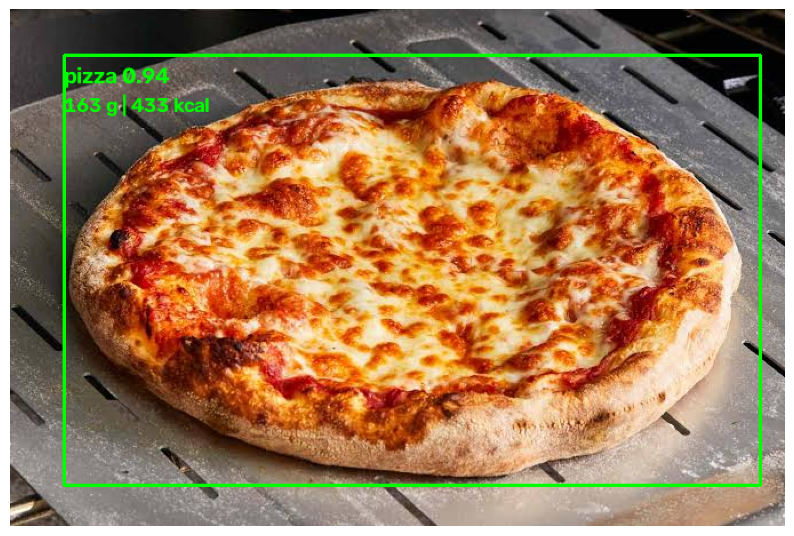

In [14]:
# ============================================================
# STEP 12
# Show End-to-End Result
# ============================================================

import matplotlib.pyplot as plt


output_image = draw_food_analysis(
    test_image,
    analysis
)

output_rgb = cv2.cvtColor(
    output_image,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10, 8))

plt.imshow(
    output_rgb
)

plt.axis("off")

plt.show()

In [15]:
# ============================================================
# STEP 13
# New Unseen Image - End-to-End Test
# ============================================================

NEW_TEST_IMAGE_PATH = (
    "/content/drive/MyDrive/Colab Notebooks/"
    "Deep Learning/Food Detection/images-6.jpeg"
)

new_test_image = cv2.imread(NEW_TEST_IMAGE_PATH)

if new_test_image is None:
    raise FileNotFoundError(
        f"Could not load image: {NEW_TEST_IMAGE_PATH}"
    )

# Complete pipeline
new_analysis = analyze_food(
    new_test_image,
    conf=0.25,
    imgsz=640
)

print("Detections:", len(new_analysis))
print()

for i, item in enumerate(new_analysis, start=1):

    print(f"--- Food {i} ---")
    print("Class:", item["class_name"])
    print("Detection confidence:", item["confidence"])
    print("BBox:", item["bbox"])
    print("Estimated mass:", item["estimated_mass_g"], "g")
    print("kcal/g:", item["kcal_per_gram"])
    print(
        "Estimated calories:",
        item["estimated_calories"],
        "kcal"
    )

Detections: 0



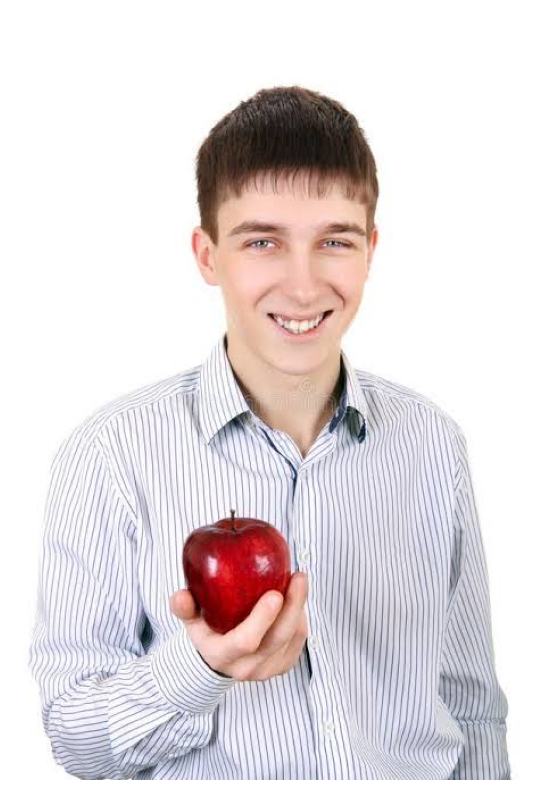

In [16]:
# ============================================================
# STEP 14
# Visualize New Unseen Image
# ============================================================

new_output = draw_food_analysis(
    new_test_image,
    new_analysis
)

new_output_rgb = cv2.cvtColor(
    new_output,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(8, 10))
plt.imshow(new_output_rgb)
plt.axis("off")
plt.show()

In [17]:
# ============================================================
# STEP 15
# Debug YOLO on unseen apple image
# ============================================================

debug_results = detection_model.predict(
    source=new_test_image,
    conf=0.01,
    imgsz=640,
    verbose=False
)

for result in debug_results:
    print("Number of boxes:", len(result.boxes))
    print()

    for box in result.boxes:
        class_id = int(box.cls[0].item())
        confidence = float(box.conf[0].item())
        class_name = detection_model.names[class_id]

        print(
            f"{class_name:20s}  "
            f"conf={confidence:.4f}"
        )

Number of boxes: 3

apple                 conf=0.0389
fried chicken         conf=0.0183
apple                 conf=0.0127


In [18]:
debug_results_1280 = detection_model.predict(
    source=new_test_image,
    conf=0.01,
    imgsz=1280,
    verbose=False
)

for result in debug_results_1280:
    print("Number of boxes:", len(result.boxes))
    print()

    for box in result.boxes:
        class_id = int(box.cls[0].item())
        confidence = float(box.conf[0].item())

        print(
            detection_model.names[class_id],
            round(confidence, 4)
        )

Number of boxes: 3

apple 0.7731
apple 0.0634
croissant 0.021


In [19]:
# ============================================================
# Adaptive Food Detection
# ============================================================

def detect_food_adaptive(
    image,
    detection_model=detection_model,
    conf=0.25,
    primary_imgsz=640,
    fallback_imgsz=1280
):
    """
    Adaptive detection strategy:

    1) Try normal inference at 640.
    2) If nothing is detected, retry at 1280.
    """

    detections = detect_food(
        image=image,
        detection_model=detection_model,
        conf=conf,
        imgsz=primary_imgsz
    )

    if len(detections) > 0:
        return detections

    detections = detect_food(
        image=image,
        detection_model=detection_model,
        conf=conf,
        imgsz=fallback_imgsz
    )

    return detections

In [20]:
# ============================================================
# Complete Adaptive A + B Integration
# ============================================================

def analyze_food(
    image,
    conf=0.25
):
    """
    Complete adaptive food analysis pipeline:

    Image
      -> Adaptive YOLO Detection
      -> Crop
      -> Mass Estimation
      -> kcal/g Lookup
      -> Calorie Estimation
    """

    if image is None or image.size == 0:
        raise ValueError("Invalid input image.")

    detections = detect_food_adaptive(
        image=image,
        conf=conf
    )

    results = []

    for detection in detections:

        x1, y1, x2, y2 = detection["bbox"]

        food_crop = image[y1:y2, x1:x2]

        if food_crop.size == 0:
            continue

        class_name = detection["class_name"]

        nutrition = estimate_food_nutrition(
            food_crop,
            class_name
        )

        results.append({
            "bbox": detection["bbox"],
            "confidence": detection["confidence"],
            "class_id": detection["class_id"],
            "class_name": class_name,
            "estimated_mass_g":
                nutrition["estimated_mass_g"],
            "kcal_per_gram":
                nutrition["kcal_per_gram"],
            "estimated_calories":
                nutrition["estimated_calories"]
        })

    return results

In [21]:
new_analysis = analyze_food(
    new_test_image,
    conf=0.25
)

print("Detections:", len(new_analysis))
print()

for i, item in enumerate(new_analysis, start=1):
    print(f"--- Food {i} ---")
    print("Class:", item["class_name"])
    print("Detection confidence:", item["confidence"])
    print("BBox:", item["bbox"])
    print("Estimated mass:", item["estimated_mass_g"], "g")
    print("kcal/g:", item["kcal_per_gram"])
    print(
        "Estimated calories:",
        item["estimated_calories"],
        "kcal"
    )
    print()

Detections: 1

--- Food 1 ---
Class: apple
Detection confidence: 0.7731
BBox: [149, 444, 249, 544]
Estimated mass: 126.18 g
kcal/g: 0.52
Estimated calories: 65.61 kcal



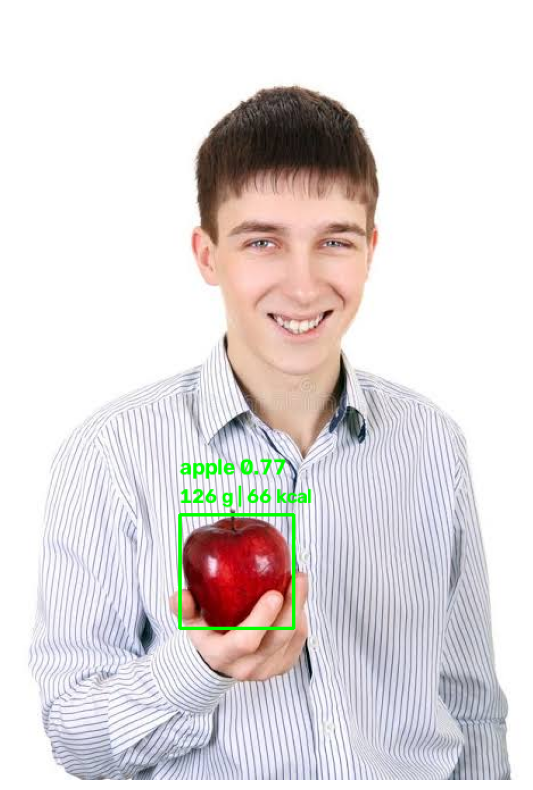

In [22]:
new_output = draw_food_analysis(
    new_test_image,
    new_analysis
)

new_output_rgb = cv2.cvtColor(
    new_output,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(8, 10))
plt.imshow(new_output_rgb)
plt.axis("off")
plt.show()